# Proyecto Python - Análisis de actividad de clientes (Sakila)

🎯 Objetivo  
El objetivo de este notebook es analizar el comportamiento de los clientes a partir de sus alquileres y pagos, asegurando la calidad de los datos y generando insights relevantes sobre ingresos y patrones de uso.

___


📂 Dataset  
Fuente: Base de datos Sakila  
Variables principales: customer_id, rental_date, return_date, amount, country, city  

___

🧠 Enfoque  
Se realizará:

- Importación de datos
- Análisis exploratorio inicial  
- Validación y limpieza de datos  
- Visualización de resultados  
- Interpretación y conclusiones finales  

___

## 1. Importación de datos


Se importa el dataset previamente procesado desde SQL, que incluye un limpieza preliminar

In [137]:
#importamos las librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from google.colab import data_table
from IPython.display import display

# Configuración para que los gráficos se vean mejor
%matplotlib inline
sns.set_theme(style="whitegrid")

print("Librerías listas para la limpieza.")


Librerías listas para la limpieza.


In [138]:
#importamos archivo csv
df = pd.read_csv('customer_activity.csv')

## 2.Análisis exploratorio inicial
### 🔍 Exploración inicial

Se realiza una primera inspección del dataset para comprender su estructura, tipos de datos y posibles inconsistencias.

- Dataset con aproximadamente 15.800 registros y 11 variables  
- No se detectan valores nulos en el dataset  
- Los datos presentan una estructura consistente tras la limpieza en SQL.

In [139]:
df.head(10)

,customer_id,first_name,last_name,email,city,country,rental_id,rental_date,return_date,payment_id,amount
0,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,76,2005-05-25 11:30:37,2005-06-03 12:00:37,1,2.99
1,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,573,2005-05-28 10:35:23,2005-06-03 06:32:23,2,0.99
2,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,1185,2005-06-15 00:54:12,2005-06-23 02:42:12,3,5.99
3,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,1422,2005-06-15 18:02:53,2005-06-19 15:54:53,4,0.99
4,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,1476,2005-06-15 21:08:46,2005-06-25 02:26:46,5,9.99
5,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,1725,2005-06-16 15:18:57,2005-06-17 21:05:57,6,4.99
6,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,2308,2005-06-18 08:41:48,2005-06-22 03:36:48,7,4.99
7,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,2363,2005-06-18 13:33:59,2005-06-19 17:40:59,8,0.99
8,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,3284,2005-06-21 06:24:45,2005-06-28 03:28:45,9,3.99
9,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,4526,2005-07-08 03:17:05,2005-07-14 01:19:05,10,5.99


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  15861 non-null  int64  
 1   first_name   15861 non-null  object 
 2   last_name    15861 non-null  object 
 3   email        15861 non-null  object 
 4   city         15861 non-null  object 
 5   country      15861 non-null  object 
 6   rental_id    15861 non-null  int64  
 7   rental_date  15861 non-null  object 
 8   return_date  15861 non-null  object 
 9   payment_id   15861 non-null  int64  
 10  amount       15861 non-null  float64
dtypes: float64(1), int64(3), object(7)
memory usage: 1.3+ MB


In [141]:
df.describe()

,customer_id,rental_id,payment_id,amount
count,15861.000000,15861.000000,15861.000000,15861.000000
mean,297.259567,7959.654562,8027.491268,4.217161
std,172.375305,4616.463306,4630.658068,2.360383
min,1.000000,1.000000,1.000000,0.990000
25%,148.000000,3968.000000,4015.000000,2.990000
50%,296.000000,7934.000000,8033.000000,3.990000
75%,446.000000,11920.000000,12036.000000,4.990000
max,599.000000,16049.000000,16049.000000,11.990000


In [142]:
df.shape

(15861, 11)

In [143]:
# Se realiza un análisis técnico , "data quality check" para analizo el dataset de forma automática y entender su calidad

# Función 1 :radiografía tecnica
def radiografia_tecnica(df):
    print("="*60)
    print(f"{' RADIOGRAFÍA DEL DATASET -#SNAPSHOT-':^60}")
    print("="*60)

    # 1. Dimensiones básicas
    filas, columnas = df.shape
    nulos_totales = df.isnull().sum().sum()
    duplicados = df.duplicated().sum()
    memoria = df.memory_usage(deep=True).sum() / (1024**2) # En MB

    print(f"  • Filas: {filas:,}")
    print(f"  • Columnas: {columnas}")
    print(f"  • Celdas totales: {df.size:,}")
    print(f"  • Datos faltantes: {nulos_totales:,} ({ (nulos_totales/df.size)*100:.2f}%)" if df.size > 0 else "  • Datos faltantes: 0")
    print(f"  • Filas duplicadas: {duplicados}")
    print(f"  • Uso de memoria: {memoria:.2f} MB")
    print("-" * 60)

    # 2. Análisis detallado por columna
    resumen_cols = pd.DataFrame({
        'Tipo': df.dtypes,
        'No Nulos': df.count(),
        'Nulos': df.isnull().sum(),
        '% Nulos': (df.isnull().sum() / filas) * 100,
        'Unicos': df.nunique(),
        'Cardinalidad (%)': (df.nunique() / filas) * 100
    })

    # Ejemplo de datos
    resumen_cols['Ejemplo'] = [df[col].dropna().iloc[0] if not df[col].dropna().empty else "N/A" for col in df.columns]

    display(resumen_cols.style.format({'% Nulos': '{:.2f}%', 'Cardinalidad (%)': '{:.2f}%'}) \
        .background_gradient(cmap='Reds', subset=['% Nulos']) \
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]},
                           {'selector': 'td', 'props': [('text-align', 'left')]}]))

    print("-" * 60)
    print(f"{' ESTADÍSTICAS NUMÉRICAS ':^60}")
    display(df.describe().T)

    print("-" * 60)
    print(f"{' DISTRIBUCIÓN DE NULOS (VISUAL) ':^60}")
    msno.matrix(df, figsize=(10,4), fontsize=9)
    plt.show()

    # Check de coherencia para "amount"
    print(" ")
    print("------------------------------------------------------------------")
    if 'amount' in df.columns:
        negativos = (df['amount'] < 0).sum()
        print(f"¿Hay montos negativos en 'amount'?: {negativos > 0} ({negativos} registros)")
    else:
        print("⚠️ La columna 'amount' no se encontró para el check de coherencia.")
    print("------------------------------------------------------------------")

# Función 2: El plan de acción (Resumen adaptado)
def plan_accion_datos(df):
    print("\n" + "="*60)
    print(f"{' 🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO ':^60}")
    print("="*60)

    # Duplicados
    duplicados = df.duplicated().sum()
    if duplicados > 0:
        print(f"  [ ] DUPLICADOS: Eliminar {duplicados} filas repetidas.")

    # Nulos
    nulos_criticos = df.columns[df.isnull().sum() / len(df) > 0.3].tolist()
    if nulos_criticos:
        print(f"  [ ] NULOS: Revisar columnas con >30% de vacío: {nulos_criticos}")

    # Montos (amount)
    if 'amount' in df.columns:
        anomalos = (df['amount'] < 0).sum()
        if anomalos > 0:
            print(f"  [ ] VALORES: Revisar {anomalos} registros con 'amount' negativo.")

    # Fechas (Específicas de tu tabla: rental_date, return_date)
    cols_fecha = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
    cols_a_convertir = [col for col in cols_fecha if not pd.api.types.is_datetime64_any_dtype(df[col])]

    if cols_a_convertir:
        print(f"  [ ] FORMATO: Convertir a datetime: {cols_a_convertir}")

    print("-" * 60)
    print("  TIP: Los campos de fecha actuales son 'object'. Cámbialos para análisis temporal.")
    print("="*60)

# Función 3: Comparativo Snapshot (Sin cambios, es universal)
def comparativo_snapshot(df_inicial, df_final):
    print("="*60)
    print(f"{' ⚖️ COMPARATIVA DE CALIDAD DE DATOS ':^60}")
    print("="*60)

    def get_metrics(df):
        return [
            f"{len(df):,}",
            df.shape[1],
            f"{df.isnull().sum().sum():,}",
            f"{(df.isnull().sum().sum() / df.size * 100 if df.size > 0 else 0):.2f}%",
            df.duplicated().sum(),
            f"{df.memory_usage(deep=True).sum() / (1024**2):.2f}"
        ]

    metrics = {
        'Métrica': ['Filas Totales', 'Columnas', 'Celdas con Nulos', '% Global de Nulos', 'Filas Duplicadas', 'Memoria (MB)'],
        'Snapshot Inicial': get_metrics(df_inicial),
        'Snapshot Final': get_metrics(df_final)
    }

    comparativa_df = pd.DataFrame(metrics)

    display(comparativa_df.style.set_properties(**{'text-align': 'center'})
            .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f0f2f6')]}])
            .hide(axis='index'))

    eliminadas = len(df_inicial) - len(df_final)
    print(f"\n✅ Se han depurado {eliminadas:,} filas en total.")
    print("="*60)

             RADIOGRAFÍA DEL DATASET -#SNAPSHOT-            
  • Filas: 15,861
  • Columnas: 11
  • Celdas totales: 174,471
  • Datos faltantes: 0 (0.00%)
  • Filas duplicadas: 0
  • Uso de memoria: 7.21 MB
------------------------------------------------------------


,Tipo,No Nulos,Nulos,% Nulos,Unicos,Cardinalidad (%),Ejemplo
customer_id,int64,15861,0,0.00%,599,3.78%,1
first_name,object,15861,0,0.00%,591,3.73%,mary
last_name,object,15861,0,0.00%,599,3.78%,smith
email,object,15861,0,0.00%,599,3.78%,mary.smith@sakilacustomer.org
city,object,15861,0,0.00%,597,3.76%,Sasebo
country,object,15861,0,0.00%,108,0.68%,Japan
rental_id,int64,15861,0,0.00%,15861,100.00%,76
rental_date,object,15861,0,0.00%,15813,99.70%,2005-05-25 11:30:37
return_date,object,15861,0,0.00%,15836,99.84%,2005-06-03 12:00:37
payment_id,int64,15861,0,0.00%,15861,100.00%,1


------------------------------------------------------------
                   ESTADÍSTICAS NUMÉRICAS                   


,count,mean,std,min,25%,50%,75%,max
customer_id,15861.0,297.259567,172.375305,1.00,148.00,296.00,446.00,599.00
rental_id,15861.0,7959.654562,4616.463306,1.00,3968.00,7934.00,11920.00,16049.00
payment_id,15861.0,8027.491268,4630.658068,1.00,4015.00,8033.00,12036.00,16049.00
amount,15861.0,4.217161,2.360383,0.99,2.99,3.99,4.99,11.99


------------------------------------------------------------
               DISTRIBUCIÓN DE NULOS (VISUAL)               


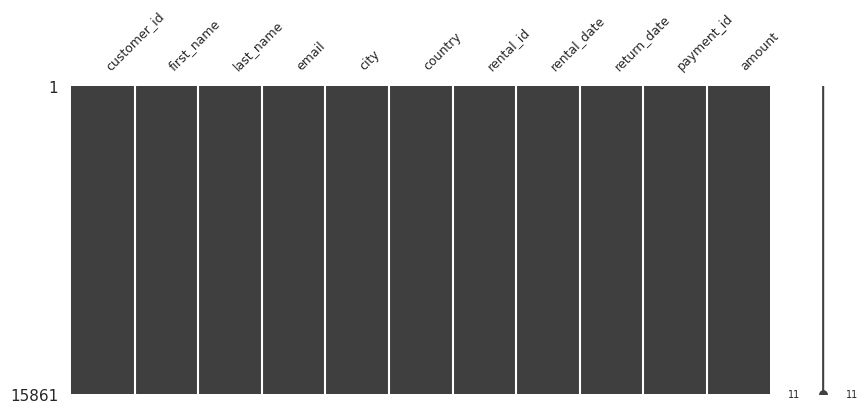

 
------------------------------------------------------------------
¿Hay montos negativos en 'amount'?: False (0 registros)
------------------------------------------------------------------

           🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO            
  [ ] FORMATO: Convertir a datetime: ['rental_date', 'return_date']
------------------------------------------------------------
  TIP: Los campos de fecha actuales son 'object'. Cámbialos para análisis temporal.


In [144]:
# Para ver el estado actual de tus 15,861 filas:
radiografia_tecnica(df)

# Para ver qué deberías limpiar:
plan_accion_datos(df)

In [145]:
# Crea un formato interactivo para DataFrames
data_table.enable_dataframe_formatter()

df.head(10)

,customer_id,first_name,last_name,email,city,country,rental_id,rental_date,return_date,payment_id,amount
0,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,76,2005-05-25 11:30:37,2005-06-03 12:00:37,1,2.99
1,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,573,2005-05-28 10:35:23,2005-06-03 06:32:23,2,0.99
2,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,1185,2005-06-15 00:54:12,2005-06-23 02:42:12,3,5.99
3,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,1422,2005-06-15 18:02:53,2005-06-19 15:54:53,4,0.99
4,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,1476,2005-06-15 21:08:46,2005-06-25 02:26:46,5,9.99
5,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,1725,2005-06-16 15:18:57,2005-06-17 21:05:57,6,4.99
6,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,2308,2005-06-18 08:41:48,2005-06-22 03:36:48,7,4.99
7,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,2363,2005-06-18 13:33:59,2005-06-19 17:40:59,8,0.99
8,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,3284,2005-06-21 06:24:45,2005-06-28 03:28:45,9,3.99
9,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,4526,2005-07-08 03:17:05,2005-07-14 01:19:05,10,5.99


##  3. Validación y limpieza de datos

En esta fase se ha realizado un proceso de validación y transformación del dataset con el objetivo de garantizar la calidad, consistencia y usabilidad de los datos para su posterior análisis.

Se han llevado a cabo las siguientes acciones:


- Conversión de fechas a formato datetime
- Todos los registros presentan valores positivos en `amount`
- Los alquileres están completos (`return_date` no nulo)
- Las variables categóricas están estandarizadas en minúsculas
- Creación de la variable derivada `rental_duration`, que representa la duración del alquiler en días, facilitando el análisis del comportamiento de los clientes.

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  15861 non-null  int64  
 1   first_name   15861 non-null  object 
 2   last_name    15861 non-null  object 
 3   email        15861 non-null  object 
 4   city         15861 non-null  object 
 5   country      15861 non-null  object 
 6   rental_id    15861 non-null  int64  
 7   rental_date  15861 non-null  object 
 8   return_date  15861 non-null  object 
 9   payment_id   15861 non-null  int64  
 10  amount       15861 non-null  float64
dtypes: float64(1), int64(3), object(7)
memory usage: 1.3+ MB


In [147]:
df.head(20)

,customer_id,first_name,last_name,email,city,country,rental_id,rental_date,return_date,payment_id,amount
0,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,76,2005-05-25 11:30:37,2005-06-03 12:00:37,1,2.99
1,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,573,2005-05-28 10:35:23,2005-06-03 06:32:23,2,0.99
2,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,1185,2005-06-15 00:54:12,2005-06-23 02:42:12,3,5.99
3,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,1422,2005-06-15 18:02:53,2005-06-19 15:54:53,4,0.99
4,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,1476,2005-06-15 21:08:46,2005-06-25 02:26:46,5,9.99
5,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,1725,2005-06-16 15:18:57,2005-06-17 21:05:57,6,4.99
6,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,2308,2005-06-18 08:41:48,2005-06-22 03:36:48,7,4.99
7,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,2363,2005-06-18 13:33:59,2005-06-19 17:40:59,8,0.99
8,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,3284,2005-06-21 06:24:45,2005-06-28 03:28:45,9,3.99
9,1,mary,smith,mary.smith@sakilacustomer.org,Sasebo,Japan,4526,2005-07-08 03:17:05,2005-07-14 01:19:05,10,5.99


In [148]:
# Convertir variables rental_date y return date a datetime

datos = ['rental_date', 'return_date']

for col in datos:
    df[col] = pd.to_datetime(df[col], errors='coerce')
print('✅ Fechas convertidas correctamente')
print(df[datos].dtypes)
df.info()

✅ Fechas convertidas correctamente
rental_date    datetime64[ns]
return_date    datetime64[ns]
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  15861 non-null  int64         
 1   first_name   15861 non-null  object        
 2   last_name    15861 non-null  object        
 3   email        15861 non-null  object        
 4   city         15861 non-null  object        
 5   country      15861 non-null  object        
 6   rental_id    15861 non-null  int64         
 7   rental_date  15861 non-null  datetime64[ns]
 8   return_date  15861 non-null  datetime64[ns]
 9   payment_id   15861 non-null  int64         
 10  amount       15861 non-null  float64       
dtypes: datetime64[ns](2), float64(1), int64(3), object(5)
memory usage: 1.3+ MB


In [149]:
# Revision de duplicados y valores nulos

total_duplicados = df.duplicated().sum()
print(f"Total de filas duplicadas: {total_duplicados}")
nulos_por_columna = df.isnull().sum()
print("Nulos por columna:")
print(nulos_por_columna[nulos_por_columna > 0])


Total de filas duplicadas: 0
Nulos por columna:
Series([], dtype: int64)


In [150]:
#Convertimos celdas que solo tienen espacios o están vacías en NaN (nulos reales),
df = df.replace(r'^\s*$', np.nan, regex=True)


print("Nulos reales detectados tras la limpieza de espacios:")
print(df.isnull().sum().sum())



print(f"\n--- RESULTADO FINAL ---")
print(f"Número de filas actual: {df.shape[0]}")

Nulos reales detectados tras la limpieza de espacios:
0

--- RESULTADO FINAL ---
Número de filas actual: 15861


In [151]:
#Normalización de texto , valores en minusculas y eliminación de espacios

df['first_name'] = df['first_name'].str.lower().str.strip()
df['last_name'] = df['last_name'].str.lower().str.strip()
df['email'] = df['email'].str.lower().str.strip()
df['city'] = df['city'].str.lower().str.strip()
df['country'] = df['country'].str.lower().str.strip()

In [152]:
# Rodeamos los datos numéricos a 2 decimales

columns_num = df.select_dtypes('number').columns
df[columns_num] = df[columns_num].round(2)
df[['amount']] = df[['amount']].astype(float)

In [153]:
df.head(20)

,customer_id,first_name,last_name,email,city,country,rental_id,rental_date,return_date,payment_id,amount
0,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,76,2005-05-25 11:30:37,2005-06-03 12:00:37,1,2.99
1,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,573,2005-05-28 10:35:23,2005-06-03 06:32:23,2,0.99
2,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,1185,2005-06-15 00:54:12,2005-06-23 02:42:12,3,5.99
3,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,1422,2005-06-15 18:02:53,2005-06-19 15:54:53,4,0.99
4,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,1476,2005-06-15 21:08:46,2005-06-25 02:26:46,5,9.99
5,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,1725,2005-06-16 15:18:57,2005-06-17 21:05:57,6,4.99
6,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,2308,2005-06-18 08:41:48,2005-06-22 03:36:48,7,4.99
7,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,2363,2005-06-18 13:33:59,2005-06-19 17:40:59,8,0.99
8,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,3284,2005-06-21 06:24:45,2005-06-28 03:28:45,9,3.99
9,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,4526,2005-07-08 03:17:05,2005-07-14 01:19:05,10,5.99


In [154]:
#Se crea un nueva variable para identificar la duracion de alquilers de nuestro dataset

df['rental_duration'] = (df['return_date'] - df['rental_date']).dt.days

df.head(20)

,customer_id,first_name,last_name,email,city,country,rental_id,rental_date,return_date,payment_id,amount,rental_duration
0,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,76,2005-05-25 11:30:37,2005-06-03 12:00:37,1,2.99,9
1,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,573,2005-05-28 10:35:23,2005-06-03 06:32:23,2,0.99,5
2,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,1185,2005-06-15 00:54:12,2005-06-23 02:42:12,3,5.99,8
3,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,1422,2005-06-15 18:02:53,2005-06-19 15:54:53,4,0.99,3
4,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,1476,2005-06-15 21:08:46,2005-06-25 02:26:46,5,9.99,9
5,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,1725,2005-06-16 15:18:57,2005-06-17 21:05:57,6,4.99,1
6,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,2308,2005-06-18 08:41:48,2005-06-22 03:36:48,7,4.99,3
7,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,2363,2005-06-18 13:33:59,2005-06-19 17:40:59,8,0.99,1
8,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,3284,2005-06-21 06:24:45,2005-06-28 03:28:45,9,3.99,6
9,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,4526,2005-07-08 03:17:05,2005-07-14 01:19:05,10,5.99,5


In [155]:
# Número de alquileres únicos por cliente
df['total_rentals'] = df.groupby('customer_id')['rental_id'].transform('nunique')

# Clasificación
df['customer_type'] = df['total_rentals'].apply(
    lambda x: 'Premium' if x > 30 else 'Regular'
)

# Verificación
print(df[['customer_id', 'total_rentals', 'customer_type']].head())

   customer_id  total_rentals customer_type
0            1             32       Premium
1            1             32       Premium
2            1             32       Premium
3            1             32       Premium
4            1             32       Premium


In [156]:
# Para facilitar la segmentación de marketing o análisis de fidelización.

print(df['customer_type'].value_counts())

customer_type
Regular    11618
Premium     4243
Name: count, dtype: int64


In [167]:
df.head(10)

,customer_id,first_name,last_name,email,city,country,rental_id,rental_date,return_date,payment_id,amount,rental_duration,total_rentals,customer_type
0,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,76,2005-05-25 11:30:37,2005-06-03 12:00:37,1,2.99,9,32,Premium
1,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,573,2005-05-28 10:35:23,2005-06-03 06:32:23,2,0.99,5,32,Premium
2,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,1185,2005-06-15 00:54:12,2005-06-23 02:42:12,3,5.99,8,32,Premium
3,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,1422,2005-06-15 18:02:53,2005-06-19 15:54:53,4,0.99,3,32,Premium
4,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,1476,2005-06-15 21:08:46,2005-06-25 02:26:46,5,9.99,9,32,Premium
5,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,1725,2005-06-16 15:18:57,2005-06-17 21:05:57,6,4.99,1,32,Premium
6,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,2308,2005-06-18 08:41:48,2005-06-22 03:36:48,7,4.99,3,32,Premium
7,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,2363,2005-06-18 13:33:59,2005-06-19 17:40:59,8,0.99,1,32,Premium
8,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,3284,2005-06-21 06:24:45,2005-06-28 03:28:45,9,3.99,6,32,Premium
9,1,mary,smith,mary.smith@sakilacustomer.org,sasebo,japan,4526,2005-07-08 03:17:05,2005-07-14 01:19:05,10,5.99,5,32,Premium


In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      15861 non-null  int64         
 1   first_name       15861 non-null  object        
 2   last_name        15861 non-null  object        
 3   email            15861 non-null  object        
 4   city             15861 non-null  object        
 5   country          15861 non-null  object        
 6   rental_id        15861 non-null  int64         
 7   rental_date      15861 non-null  datetime64[ns]
 8   return_date      15861 non-null  datetime64[ns]
 9   payment_id       15861 non-null  int64         
 10  amount           15861 non-null  float64       
 11  rental_duration  15861 non-null  int64         
 12  total_rentals    15861 non-null  int64         
 13  customer_type    15861 non-null  object        
dtypes: datetime64[ns](2), float64(1), int6

## 📊 4. Visualización

Tras el proceso de limpieza, se ha realizado una fase de visualización y representaciones gráficas que permiten analizar la distribución de ingresos, la duración de los alquileres y los patrones de comportamiento de los clientes.  
Estas visualizaciones facilitan la identificación de tendencias y la comparación entre distintas regiones.

In [176]:
# Se detectan outliers en nuestro dataset, filtrando valores minimos y máximos

df['amount'].nsmallest(5)

,amount
1,0.99
3,0.99
7,0.99
17,0.99
18,0.99


In [177]:
df['amount'].nlargest(5)

,amount
338,11.99
3099,11.99
5212,11.99
5213,11.99
5480,11.99


<Axes: >

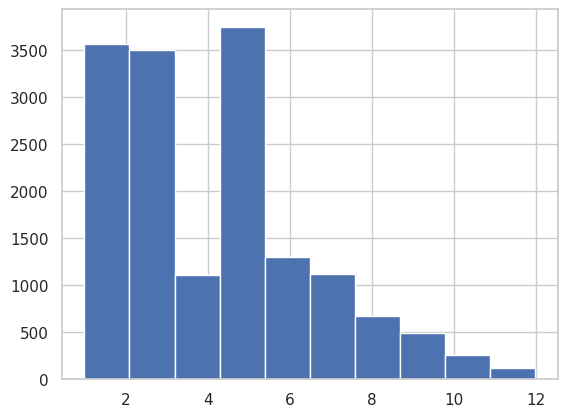

In [160]:
#se realiza validación visual mediante histograma en la variable 'amount'.

df['amount'].describe()
df['amount'].hist()

In [161]:
# Agrupar ingresos por país

country_revenue = df.groupby('country')['amount'].sum()

# Seleccionar top 10

top_countries = country_revenue.sort_values(ascending=False).head(10)

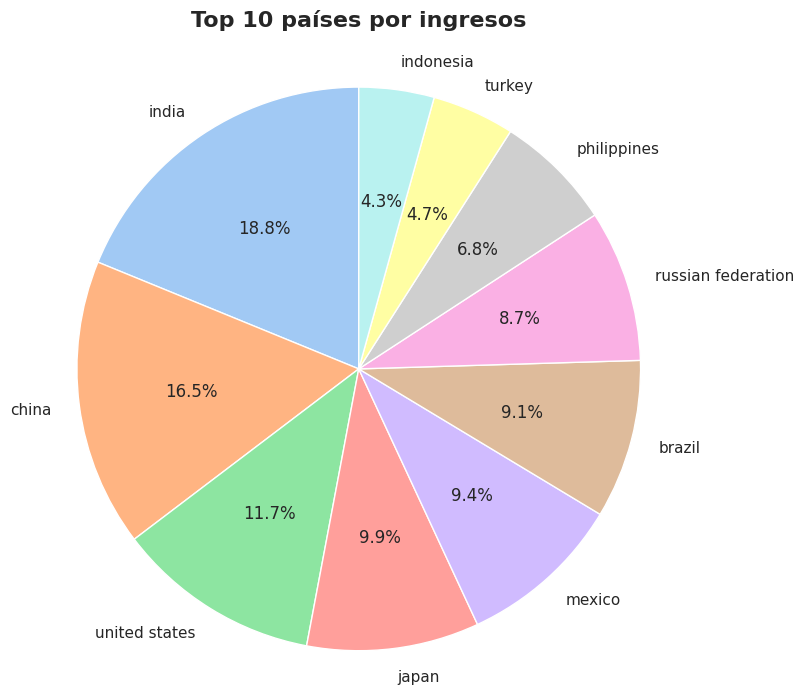

In [162]:
plt.figure(figsize=(8, 8))

plt.pie(

 top_countries,

 labels=top_countries.index,

 autopct='%1.1f%%',

 startangle=90,

 colors=sns.color_palette('pastel')

)

plt.title(

'Top 10 países por ingresos',

 pad=25,

 fontsize=16,

 fontweight='bold'

)

plt.axis('equal')

plt.show()

In [163]:
# Agrupar datos para ver duracion media de alquiler pos paises

avg_duration_country = (
    df.groupby('country')['rental_duration']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

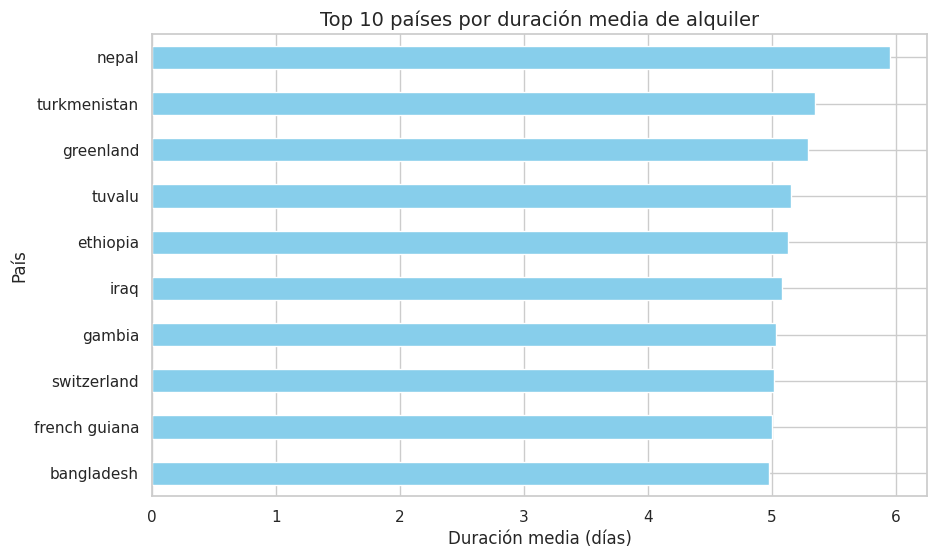

In [164]:
# Gráfico que muestra duracion media de alquiler por paises, teniendo en cuenta los 10 con alquiler mas largo

plt.figure(figsize=(10,6))

avg_duration_country.sort_values().plot(
    kind='barh',
    color='skyblue'
)

plt.title('Top 10 países por duración media de alquiler', fontsize=14)
plt.xlabel('Duración media (días)')
plt.ylabel('País')

plt.show()

In [165]:
#Se agrupan los datos por país para obtener el total de ingresos y la duración media de los alquileres.

df.groupby('country').agg({
    'amount': 'sum',
    'rental_duration': 'mean'
}).round(2).sort_values(by='amount', ascending=False).head(10)

,amount,rental_duration
country,,
india,6561.52,4.53
china,5757.87,4.43
united states,4081.43,4.67
japan,3447.84,4.37
mexico,3293.10,4.35
brazil,3177.59,4.58
russian federation,3037.91,4.50
philippines,2355.42,4.61
turkey,1651.15,4.53


In [166]:
# Para exportar el dataset final

df.to_csv('clean_customer_activity.csv', index=False)

## 📌 Conclusiones

- Los ingresos se concentran en un número reducido de países.
- La duración de los alquileres varía entre regiones, indicando distintos patrones de uso.
- No se detectan problemas significativos en la calidad de los datos.
- El dataset presenta una estructura consistente y adecuada para análisis posteriores.

Este análisis permite comprender mejor el comportamiento de los clientes y detectar posibles oportunidades de optimización en función de la región.